# Accelerated Stability Study: Analysis of Two Prototype Formulations

This notebook analyses an accelerated stability dataset for two prototype formulations of
the same product (Lot A014 and Lot B025). Samples were held at combinations of temperature
and relative humidity for varying durations, then tested in duplicate for assay
(active ingredient remaining) and two degradation products (Impurity RRT 0.92 and RRT 1.23).

The notebook is organised around the six questions in the brief:

1. Key features of the dataset
2. Insights from the data
3. Factors influencing degradation
4. Relative performance of the two formulations
5. Additional insight through modelling
6. Limitations and proposed future work

All statistical conclusions should be read as tentative given the small sample size
(20 stressed conditions plus one control per formulation).

## Setup and Data Loading

Load the two datasets. Drop the two top rows to do the analysis. Check the sheets and data types.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [ ]:
PATH = "KTP_task_datasets.xls"
column_names = ["start","pull","set_down","days","oven","temp","rh","analyst",
                "assay1","assay2","imp092_1","imp092_2","imp123_1","imp123_2"]
df_A = pd.read_excel(PATH, sheet_name='Lot A014', names=column_names, skiprows=2, header=None)
df_B = pd.read_excel(PATH, sheet_name='Lot B025', names=column_names, skiprows=2, header=None)
df_A.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   start     19 non-null     datetime64[us]
 1   pull      19 non-null     datetime64[us]
 2   set_down  20 non-null     int64         
 3   days      20 non-null     int64         
 4   oven      20 non-null     str           
 5   temp      20 non-null     object        
 6   rh        20 non-null     object        
 7   analyst   20 non-null     str           
 8   assay1    20 non-null     float64       
 9   assay2    20 non-null     float64       
 10  imp092_1  20 non-null     float64       
 11  imp092_2  20 non-null     float64       
 12  imp123_1  20 non-null     float64       
 13  imp123_2  20 non-null     float64       
dtypes: datetime64[us](2), float64(6), int64(2), object(2), str(2)
memory usage: 2.5+ KB


In [3]:
df_B.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   start     19 non-null     datetime64[us]
 1   pull      19 non-null     datetime64[us]
 2   set_down  20 non-null     int64         
 3   days      20 non-null     int64         
 4   oven      20 non-null     str           
 5   temp      20 non-null     object        
 6   rh        20 non-null     object        
 7   analyst   20 non-null     str           
 8   assay1    20 non-null     float64       
 9   assay2    20 non-null     float64       
 10  imp092_1  20 non-null     float64       
 11  imp092_2  20 non-null     float64       
 12  imp123_1  20 non-null     float64       
 13  imp123_2  20 non-null     float64       
dtypes: datetime64[us](2), float64(6), int64(2), object(2), str(2)
memory usage: 2.5+ KB


## Data Cleaning
Define the control rows. This helps in analysing the database.
Temperature and rho should be numerical values but they are objects. So, convert them to the numerical values.
Take the mean of two readings.

In [4]:
def clean_data(df, lot_label):
    df = df.copy()
    for c in ['oven','temp','rh']:
        df[c] = df[c].astype(str).str.strip()
    control = df[df['temp'] == 'control'].copy()
    df = df[df['temp'] != 'control'].copy()
    for c in ["days","temp","rh","assay1","assay2","imp092_1","imp092_2","imp123_1","imp123_2"]:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    for t in (df, control):
        t["assay"] = t[["assay1","assay2"]].mean(axis=1)
        t["imp092"] = t[["imp092_1","imp092_2"]].mean(axis=1)
        t["imp123"] = t[["imp123_1","imp123_2"]].mean(axis=1)
    df["lot"] = lot_label
    control["lot"] = lot_label
    return df, control
df_A, control_A = clean_data(df_A, "A014")
df_B, control_B = clean_data(df_B, "B025")
df = pd.concat([df_A, df_B], ignore_index=True)
control = pd.concat([control_A, control_B], ignore_index=True)

## Section 1. Key Features

In [5]:
print("Stressed-sample shape:", df.shape)
print("Missing values in stressed samples:", int(df.isnull().sum().sum()))
print("-----------------------------------------------------")
print("Temperatures (C):", sorted(df["temp"].unique()))
print("Relative humidities (%):", sorted(df["rh"].unique()))
print("Exposure durations (days):", sorted(df["days"].unique()))
print("Analysts:", sorted(df["analyst"].unique()))
print("Samples per lot:", df["lot"].value_counts().to_dict())

Stressed-sample shape: (38, 18)
Missing values in stressed samples: 0
-----------------------------------------------------
Temperatures (C): [np.int64(50), np.int64(60), np.int64(65), np.int64(70)]
Relative humidities (%): [np.int64(11), np.int64(21), np.int64(25), np.int64(41), np.int64(42), np.int64(63), np.int64(64), np.int64(79), np.int64(80)]
Exposure durations (days): [np.int64(1), np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(14), np.int64(17), np.int64(19), np.int64(20), np.int64(21)]
Analysts: ['CM ', 'RG', 'SS']
Samples per lot: {'A014': 19, 'B025': 19}


In [6]:
# Control (baseline) values
control[["lot", "assay", "imp092", "imp123"]]

,lot,assay,imp092,imp123
0,A014,12.7990,0.0,0.075
1,B025,12.6065,0.0,0.143


In [7]:
df_A.describe()

,start,pull,set_down,days,temp,rh,assay1,assay2,imp092_1,imp092_2,imp123_1,imp123_2,assay,imp092,imp123
count,19,19,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,2025-12-26 03:47:22.105263,2026-01-07 21:28:25.263158,8.263158,12.736842,62.631579,48.210526,11.413263,11.433053,0.342737,0.333105,0.288053,0.289158,11.423158,0.337921,0.288605
min,2025-12-18 00:00:00,2026-01-07 00:00:00,0.000000,1.000000,50.000000,11.000000,8.185000,8.119000,0.136000,0.132000,0.074000,0.074000,8.152000,0.134000,0.074000
25%,2025-12-18 00:00:00,2026-01-08 00:00:00,0.000000,5.500000,60.000000,25.000000,11.190500,11.194500,0.222500,0.213000,0.171500,0.173500,11.220500,0.219500,0.172500
50%,2025-12-25 00:00:00,2026-01-08 00:00:00,7.000000,14.000000,65.000000,42.000000,11.912000,11.877000,0.288000,0.282000,0.198000,0.200000,11.930000,0.285000,0.199000
75%,2026-01-02 00:00:00,2026-01-08 00:00:00,15.500000,21.000000,70.000000,64.000000,12.125000,12.226500,0.518500,0.461500,0.383000,0.386000,12.199750,0.501500,0.384500
max,2026-01-07 00:00:00,2026-01-08 00:00:00,20.000000,21.000000,70.000000,80.000000,12.533000,12.545000,0.651000,0.673000,0.748000,0.746000,12.539000,0.662000,0.747000
std,NaN,NaN,8.088690,8.088690,6.945906,24.279802,1.231985,1.257570,0.160109,0.161173,0.182870,0.183791,1.236471,0.159822,0.183321


In [8]:
df_B.describe()

,start,pull,set_down,days,temp,rh,assay1,assay2,imp092_1,imp092_2,imp123_1,imp123_2,assay,imp092,imp123
count,19,19,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,2025-12-26 03:47:22.105263,2026-01-07 21:28:25.263158,8.263158,12.736842,62.631579,48.210526,11.333421,11.334368,0.364842,0.348263,0.389474,0.388842,11.333895,0.356553,0.389158
min,2025-12-18 00:00:00,2026-01-07 00:00:00,0.000000,1.000000,50.000000,11.000000,8.439000,7.993000,0.134000,0.135000,0.113000,0.113000,8.216000,0.134500,0.113000
25%,2025-12-18 00:00:00,2026-01-08 00:00:00,0.000000,5.500000,60.000000,25.000000,10.941500,10.918000,0.244500,0.222500,0.260500,0.260500,10.978750,0.240000,0.260500
50%,2025-12-25 00:00:00,2026-01-08 00:00:00,7.000000,14.000000,65.000000,42.000000,11.677000,11.734000,0.304000,0.301000,0.310000,0.316000,11.825500,0.296000,0.313000
75%,2026-01-02 00:00:00,2026-01-08 00:00:00,15.500000,21.000000,70.000000,64.000000,12.188500,12.147500,0.496000,0.478000,0.499500,0.497500,12.150750,0.487000,0.498500
max,2026-01-07 00:00:00,2026-01-08 00:00:00,20.000000,21.000000,70.000000,80.000000,12.419000,12.387000,0.737000,0.700000,0.888000,0.882000,12.347500,0.718500,0.885000
std,NaN,NaN,8.088690,8.088690,6.945906,24.279802,1.161034,1.249229,0.173587,0.163723,0.206744,0.204951,1.198457,0.168318,0.205838


**Observations**

- Small dataset: 20 stressed conditions plus one control per formulation. Statistical power
  is limited and conclusions are exploratory.
- Four temperatures (50, 60, 65, 70 C) and several relative humidities (11 to 80 %) are used,
  but the design is **not fully factorial**: not every temperature appears at every humidity,
  so temperature and humidity effects are partly confounded.
- Exposure durations span 1 to 21 days. All samples share a common pull date with different
  set-down days, i.e. a set-down design rather than repeated sampling of a single batch.
- Duplicate agreement is tight for the impurities (mean absolute difference of the order of
  0.003 to 0.02 percent) and looser for assay (around 0.2 mg/tablet), which is expected.
- The control shows zero RRT 0.92 and a small non-zero RRT 1.23, which is relevant to how each
  impurity is interpreted below.
- A single analyst is recorded per condition, so any analyst effect is confounded with the
  condition and cannot be isolated.

## Section 2: Insights from the data (Q2)

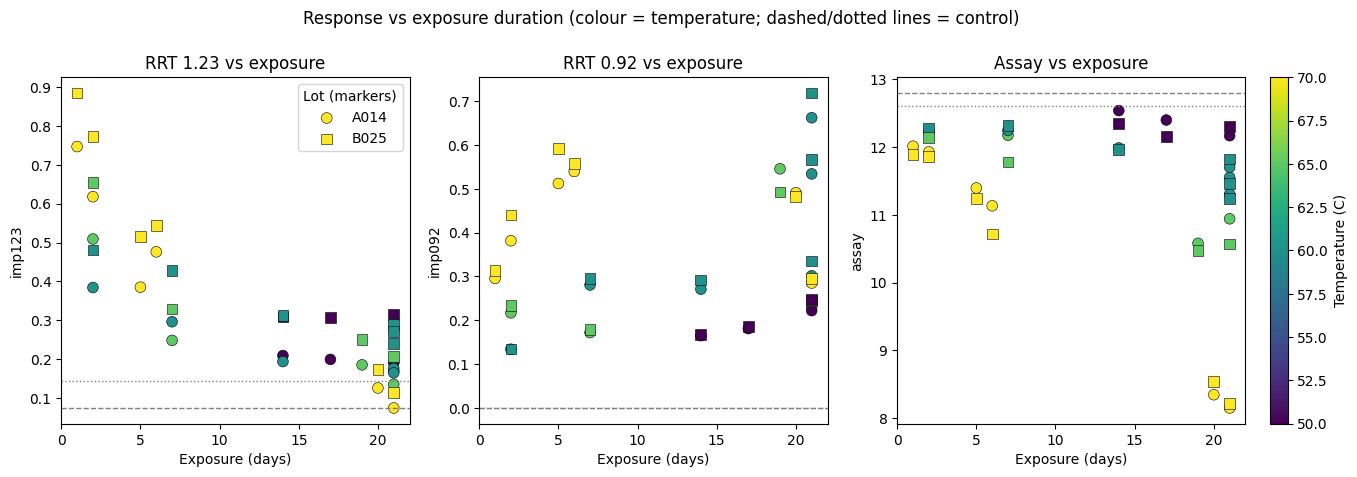

In [9]:
def scatter_vs_exposure(ax, response, ctrl_col, title):
    for lot, marker in [("A014", "o"), ("B025", "s")]:
        s = df[df["lot"] == lot]
        sc = ax.scatter(s["days"], s[response], c=s["temp"],
                        cmap="viridis", marker=marker, s=60, edgecolor="k",
                        linewidth=0.4, label=lot)
    for lot, style in [("A014", "--"), ("B025", ":")]:
        val = control[control["lot"] == lot][ctrl_col].iloc[0]
        ax.axhline(val, linestyle=style, color="grey", linewidth=1)
    ax.set_xlabel("Exposure (days)")
    ax.set_ylabel(response)
    ax.set_title(title)
    return sc

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
scatter_vs_exposure(axes[0], "imp123", "imp123", "RRT 1.23 vs exposure")
scatter_vs_exposure(axes[1], "imp092", "imp092", "RRT 0.92 vs exposure")
sc = scatter_vs_exposure(axes[2], "assay", "assay", "Assay vs exposure")
axes[0].legend(title="Lot (markers)", loc="upper right")
cbar = fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("Temperature (C)")
plt.suptitle("Response vs exposure duration (colour = temperature; dashed/dotted lines = control)", y=1.03)
plt.show()

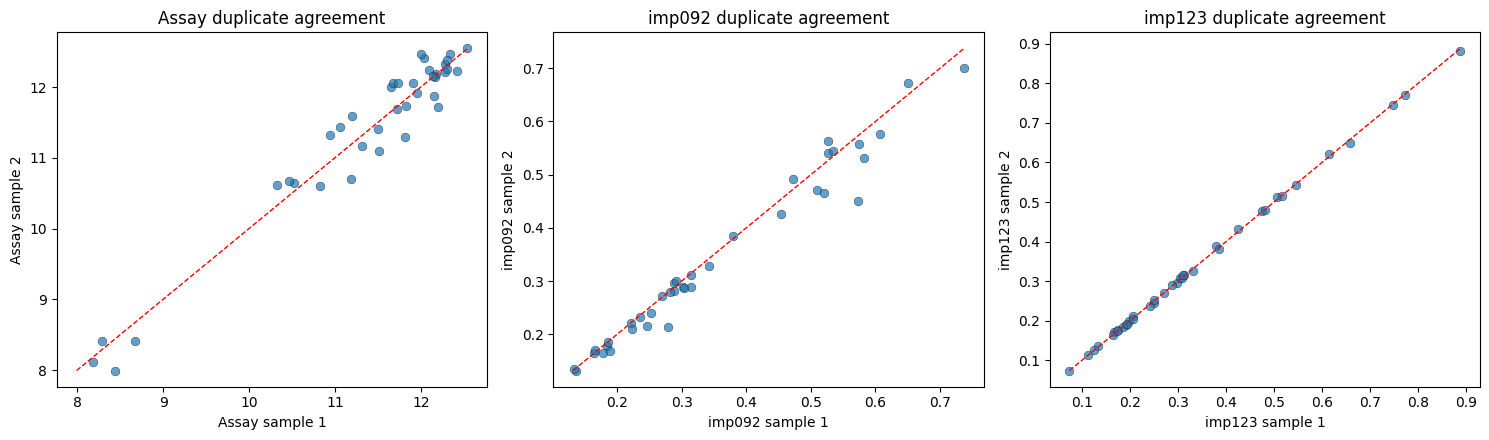

In [10]:
# Duplicate reproducibility: sample 1 vs sample 2
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [("assay1", "assay2", "Assay"),
         ("imp092_1", "imp092_2", "imp092"),
         ("imp123_1", "imp123_2", "imp123")]
for ax, (s1, s2, label) in zip(axes, pairs):
    ax.scatter(df[s1], df[s2], s=40, alpha=0.7, edgecolor="k", linewidth=0.3)
    lo = min(df[s1].min(), df[s2].min())
    hi = max(df[s1].max(), df[s2].max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_xlabel(f"{label} sample 1"); ax.set_ylabel(f"{label} sample 2")
    ax.set_title(f"{label} duplicate agreement")
plt.tight_layout(); plt.show()

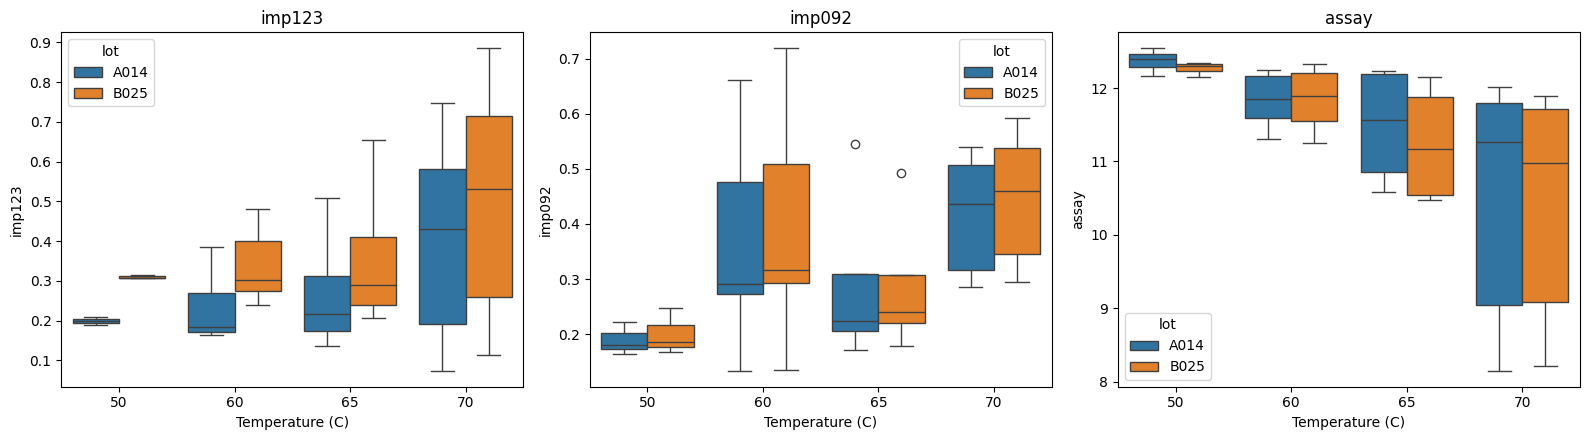

In [11]:
# Distribution of each response by temperature, split by lot
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, resp in zip(axes, ["imp123", "imp092", "assay"]):
    sns.boxplot(data=df, x="temp", y=resp, hue="lot", ax=ax)
    ax.set_xlabel("Temperature (C)"); ax.set_title(resp)
plt.tight_layout(); plt.show()

**Interpretation**

- The two impurities behave in opposite directions. **RRT 0.92 increases** with stress and time,
  consistent with an accumulating degradation product. **RRT 1.23 decreases** with exposure,
  which is unusual for a degradant and is examined directly in Section 3.
- **Assay falls** at the harshest condition (70 C), the expected signature of active-ingredient
  loss.
- Duplicate measurements lie close to the line of identity, supporting the analytical
  reproducibility of the method.

## Section 3: Factors influencing degradation (Q3)

The striking feature of the data is that RRT 0.92 and RRT 1.23 respond to exposure in opposite
directions.

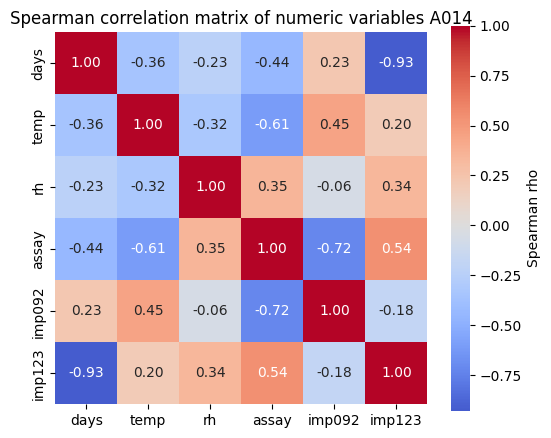

In [12]:
num_cols = ["days","temp","rh","assay", "imp092", "imp123"]
corr_matrix = df_A[num_cols].corr(method="spearman")
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"label": "Spearman rho"})
plt.title("Spearman correlation matrix of numeric variables A014")
plt.show()

In [13]:
same = df_A[(df_A["temp"] == 70) & (df_A["rh"] == 11)]
print(same[["days", "imp123"]].sort_values("days"))

    days  imp123
14     5   0.385
0     21   0.074


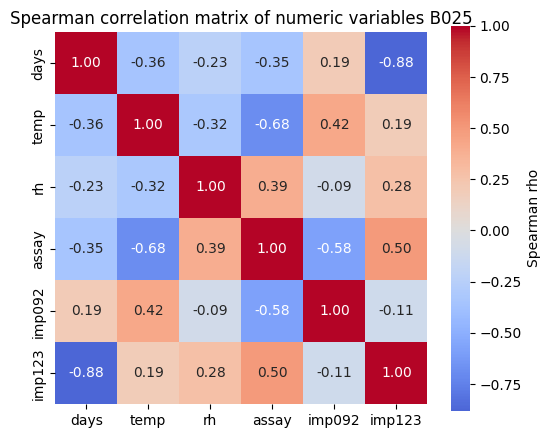

In [14]:
num_cols = ["days","temp","rh","assay", "imp092", "imp123"]
corr_matrix = df_B[num_cols].corr(method="spearman")
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"label": "Spearman rho"})
plt.title("Spearman correlation matrix of numeric variables B025")
plt.show()

In [15]:
same = df_B[(df_B["temp"] == 70) & (df_B["rh"] == 11)]
print(same[["days", "imp123"]].sort_values("days"))

    days  imp123
14     5   0.516
0     21   0.113


Within a fixed temperature and humidity, increasing exposure consistently raises RRT 0.92 and
lowers assay, while RRT 1.23 falls. This rules out condition-confounding as the explanation:
RRT 1.23 is genuinely being consumed over time. A plausible reading is that RRT 1.23 is a
reactive intermediate or a starting-material-related species that converts onward, whereas
RRT 0.92 is the terminal degradation product that accumulates. This should be confirmed
analytically (for example by mass balance) and is noted as a hypothesis rather than a
conclusion.

In [16]:
rows = []
for pred in ["days", "temp", "rh"]:
    for resp in ["imp123", "imp092", "assay"]:
        for lot in ["A014", "B025"]:
            s = df[(df["lot"] == lot)]
            rho, p = stats.spearmanr(s[pred], s[resp])
            rows.append({"lot": lot, "predictor": pred, "response": resp,
                         "rho": round(rho, 2), "p_value": round(p, 4)})
print(pd.DataFrame(rows))

     lot predictor response   rho  p_value
0   A014      days   imp123 -0.93   0.0000
1   B025      days   imp123 -0.88   0.0000
2   A014      days   imp092  0.23   0.3502
3   B025      days   imp092  0.19   0.4308
4   A014      days    assay -0.44   0.0597
5   B025      days    assay -0.35   0.1416
6   A014      temp   imp123  0.20   0.4126
7   B025      temp   imp123  0.19   0.4370
8   A014      temp   imp092  0.45   0.0542
9   B025      temp   imp092  0.42   0.0719
10  A014      temp    assay -0.61   0.0055
11  B025      temp    assay -0.68   0.0013
12  A014        rh   imp123  0.34   0.1527
13  B025        rh   imp123  0.28   0.2480
14  A014        rh   imp092 -0.06   0.8129
15  B025        rh   imp092 -0.09   0.7008
16  A014        rh    assay  0.35   0.1472
17  B025        rh    assay  0.39   0.0965


**Conclusions**

- Exposure duration is the dominant correlate of both impurities, but in opposite directions
  (positive for RRT 0.92 within fixed conditions, strongly negative for RRT 1.23).
- Temperature is the main driver of assay loss, visible as the sharp drop at 70 C.
- Humidity shows a weaker, positive association with RRT 0.92.

## Section 4: Relative performance of the two formulations (Q4)

The two lots share the same set of conditions, so they can be compared as matched pairs. The Wilcoxon signed-rank test is used because the sample is small and normality cannot be assumed.

In [17]:
pair = pd.merge(df_A, df_B, on=["days", "temp", "rh"], suffixes=("_x", "_y"))
results = []
for name in ["imp123", "imp092", "assay"]:
    gap = (pair[f"{name}_y"] - pair[f"{name}_x"]).mean()
    stat, p = stats.wilcoxon(pair[f"{name}_y"], pair[f"{name}_x"])
    results.append({"response": name,
                    "mean_diff_B_minus_A": gap,
                    "wilcoxon_stat": stat, "p_value": p})
pd.DataFrame(results)

,response,mean_diff_B_minus_A,wilcoxon_stat,p_value
0,imp123,0.100553,0.0,0.000132
1,imp092,0.018632,21.0,0.002899
2,assay,-0.089263,50.0,0.072834


**Conclusions**
- Lot A014 shows significantly lower levels of both impurities than Lot B025 across matched conditions (positive B-minus-A differences with small p-values for RRT 0.92 and RRT 1.23).
- Assay loss is marginally greater for Lot B025, but the difference is not statistically significant at the 5 percent level.

## Section 5: Additional insight through modelling (Q5)

Two complementary models are fitted.

**Model 1** is an exploratory multiple linear regression of each accumulating response on exposure, temperature and humidity, to describe the direction and relative size of the effects.

**Model 2** is the moisture-modified Arrhenius model used in accelerated predictive stability work. It expresses the degradation rate constant as

ln(k) = ln(A) - Ea/(R T) + B x RH

where k is the rate (here approximated as the accumulated change divided by exposure days), T is temperature in Kelvin, Ea is the activation energy and B is the humidity sensitivity constant. The model is applied to the genuinely accumulating responses (RRT 0.92 and assay loss). It is **not** applied to RRT 1.23, because that species decreases over time and so is not described by an accumulation rate. Activation energy and humidity sensitivity are then compared between the two formulations.

In [18]:
R = 8.314
base = control['assay'].iloc[0] 
data = []
for df in ["df_A", "df_B"]:
    rate = (base - eval(df)['assay']) / eval(df)['days']
    keep = rate > 0
    x = np.column_stack([1/(eval(df)['temp'][keep] + 273.15), eval(df)['rh'][keep]])
    y = np.log(rate[keep])
    model = LinearRegression().fit(x, y)
    Ea = -model.coef_[0] * R/1000  # Convert J/mol to kJ/mol
    data.append({"lot": df, "Ea": Ea, "humidity_coefficient": model.coef_[1], "R2": model.score(x, y)})
df_results = pd.DataFrame(data)
print(df_results)

    lot          Ea  humidity_coefficient        R2
0  df_A  132.499149              0.013691  0.859874
1  df_B  128.624052              0.014126  0.855695


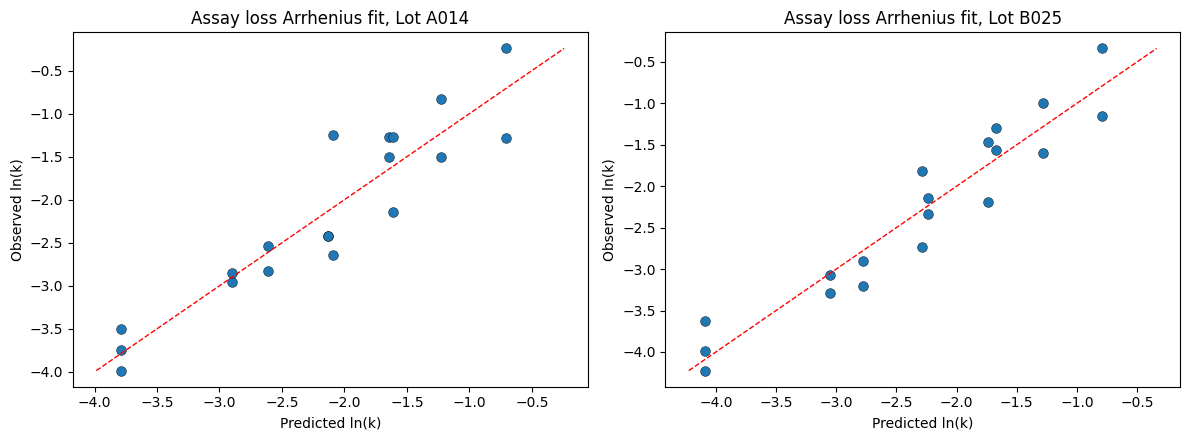

In [19]:
fits = {}
for lot, dfx, ctrl in [("A014", df_A, control_A), ("B025", df_B, control_B)]:
    s = dfx.copy()
    base = ctrl["assay"].iloc[0]
    k = (base - s["assay"]) / s["days"]      # the rate, kept aligned to s
    mask = k > 0
    X = np.column_stack([1.0/(s.loc[mask, "temp"] + 273.15), s.loc[mask, "rh"]])
    y = np.log(k[mask])
    m = LinearRegression().fit(X, y)
    fits[(lot, "assay")] = (m, s, mask, k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, lot in zip(axes, ["A014", "B025"]):
    m, s, mask, k = fits[(lot, "assay")]
    X = np.column_stack([1.0 / (s.loc[mask, "temp"] + 273.15), s.loc[mask, "rh"]])
    y = np.log(k[mask])
    ax.scatter(m.predict(X), y, s=50, edgecolor="k", linewidth=0.3)
    lo, hi = y.min(), y.max()
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_xlabel("Predicted ln(k)"); ax.set_ylabel("Observed ln(k)")
    ax.set_title(f"Assay loss Arrhenius fit, Lot {lot}")
plt.tight_layout(); plt.show()


**Modelling discussion**

- The multiple linear regression confirms the directions seen earlier: RRT 0.92 rises with exposure and temperature, assay falls with temperature.

## Section 6: Limitations and future work (Q6)

**Limitations**

- Small sample: 20 stressed conditions and one control per formulation; all inferences are exploratory.
- Most conditions were tested at a single exposure duration, so within-condition time courses (and therefore rate constants) are weakly determined.
- A single batch per formulation means batch-to-batch variability is unknown.
- Exposure durations are short (1 to 21 days) and there is no real-time data at the intended storage condition, so long-term and non-linear behaviour is unobserved.
- RRT 1.23 decreases over time; its role (intermediate, starting-material-related species, or measurement artefact) is unresolved and warrants analytical follow-up.

**Future priorities**

1. Multiple time points per condition (for example 1, 2, 4, 7, 14, 21 days) to fit true
   degradation kinetics at each condition.
2. At least three batches per formulation to support ICH Q1E shelf-life estimation.
3. Inclusion of the intended real-time storage condition (for example 25 C / 60 percent RH).
4. Mass-balance and structural work to identify RRT 1.23 and explain its decline.
5. Randomised or blinded analyst assignment to remove the analyst-condition confound.